In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('whitegrid')

pd.set_option('display.float_format', '{:.2f}'.format)

print('All imports successful.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

All imports successful.
Pandas version: 3.0.2
NumPy version: 2.4.4


In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape}')  # (rows, columns)
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Dataset loaded successfully.
Shape: (7043, 21)
Memory usage: 1908.7 KB


In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
print('Columns:')
for col in df.columns:
    print(f'  {col}')

Columns:
  customerID
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  InternetService
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  Contract
  PaperlessBilling
  PaymentMethod
  MonthlyCharges
  TotalCharges
  Churn


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [7]:
df.describe(include='object')

C:\Users\HP\AppData\Local\Temp\ipykernel_13320\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [9]:
tc_converted = pd.to_numeric(df['TotalCharges'], errors='coerce')

problem_rows = df[tc_converted.isnull()]
print(f'Rows where TotalCharges is not a valid number: {len(problem_rows)}')
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Rows where TotalCharges is not a valid number: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn counts:')
print(churn_counts)
print('\nChurn percentages:')
print(churn_pct.round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_13320\3312601423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


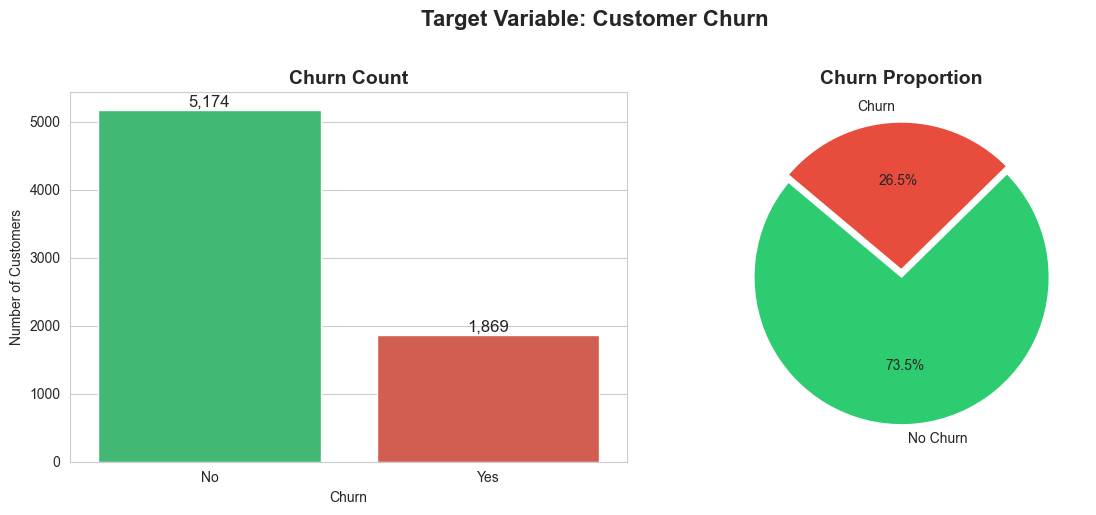

Plot saved to reports/figures/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Count plot
sns.countplot(
    data=df,
    x='Churn',
    palette=['#2ecc71', '#e74c3c'],  # green = stay, red = churn
    ax=axes[0]
)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')


for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )

# Right: Pie chart
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=140,
    explode=(0, 0.05)  # slightly pull out the churn slice for emphasis
)
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Plot saved to reports/figures/')

In [12]:
id_cols = ['customerID']
target_col = ['Churn']

# Numerical columns 
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = [
    col for col in df.select_dtypes(include='object').columns
    if col not in id_cols + target_col
]

print(f'Identifier columns: {id_cols}')
print(f'\nNumerical columns ({len(numerical_cols)}): {numerical_cols}')
print(f'\nCategorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'\nTarget: {target_col}')

Identifier columns: ['customerID']

Numerical columns (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Target: ['Churn']


C:\Users\HP\AppData\Local\Temp\ipykernel_13320\3713128966.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include='object').columns


In [13]:
print('Unique values per categorical column:')
print('-' * 50)
for col in categorical_cols:
    uniques = df[col].unique()
    print(f'\n{col} ({len(uniques)} unique): {uniques}')

Unique values per categorical column:
--------------------------------------------------

gender (2 unique): <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner (2 unique): <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents (2 unique): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService (2 unique): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines (3 unique): <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService (3 unique): <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity (3 unique): <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup (3 unique): <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection (3 unique): <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport (3 unique): <ArrowStringArray>
['No', 'Yes', 'No internet servi